# ⚙️ Capstone Case Study — Predictive Maintenance for Rotating Machinery
### A Day-8 walkthrough: the full classification workflow, start to finish

---
## 1. Business / engineering problem statement

**Context (Mechanical Engineering — rotating equipment):** A plant runs a fleet of CNC / rotating machines. Unplanned **failures** stop production, damage tooling and create safety risk. The maintenance team logs sensor and operating data on every run and wants to **predict whether a run will end in failure**, so they can intervene early (inspect, slow down, swap a tool) instead of running to breakdown.

**Goal:** build and evaluate a **binary classifier** for `failure` from the operating snapshot. Because a *missed failure* (false negative) is far costlier than a *false alarm*, we care about **recall and ROC-AUC**, not raw accuracy — and we'll tune the decision threshold to the real cost of errors.

**Data (provided — keep both beside this notebook / upload in Colab):**

| File | Grain | Contents |
| ---- | ----- | -------- |
| `pdm_sensor_logs.csv` | one row / machine run | sensor + operating snapshot + `failure` (target) |
| `pdm_machine_registry.xlsx` | one row / machine | static info: quality variant, commission year, rated torque |

## 2. What we'll apply (Day 8 skills)

| Stage | Skill |
| ----- | ----- |
| Frame & assemble | join sources, hunt leakage, stratified split, leak-free pipeline |
| Baseline | **U16 Part 1** — logistic regression, probabilities, the threshold |
| Evaluate | **U16 Part 1** — confusion matrix, precision/recall/F1, ROC-AUC |
| Stronger models | **U16 Part 2** — trees, random forest, gradient boosting |
| Tune & decide | **U16 Part 2** — grid search, class imbalance, threshold for cost |
| Explain | feature importance → maintenance guidance |

## 3. Setup

In [1]:
# === SETUP: load the two provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd


QUALITY = {"L": 0.6, "M": 0.0, "H": -0.5}   # build quality -> failure-risk offset (H = lower risk)


def build_pdm(logs_csv="pdm_sensor_logs.csv", registry_xlsx="pdm_machine_registry.xlsx",
              seed=8, verbose=False):
    """Predictive maintenance for rotating machinery — a mechanical-engineering
    binary CLASSIFICATION problem. Each row is a machine's operating snapshot; the
    target is whether that run ended in a FAILURE.

    Failures are driven by physically-motivated stress modes:
      - overstrain      : high tool wear x high torque
      - heat dissipation: small (process - air) temperature gap at low speed
      - power           : mechanical power (torque x speed) outside a safe band
      - build quality   : L-variant machines fail more, H-variant less
    plus random wear. Target rate is deliberately imbalanced (~7%).

    Two joinable sources (on machine_id):
      - pdm_sensor_logs.csv     : per-run sensor + operating snapshot + failure (target)
      - pdm_machine_registry.xlsx : per-machine static info (quality variant, commission year, rated torque)

    Built-in realism:
      - mixed numeric + categorical features on different scales
      - a DELIBERATELY LEAKY column 'unplanned_downtime_min' (only > 0 after a failure)
      - a 'failure_mode' column for a multiclass extension
      - some missing values and duplicate rows
    """
    rng = np.random.default_rng(seed)
    N = 3000
    machines = [f"M{idx:03d}" for idx in range(1, 41)]
    m_quality = {m: rng.choice(list(QUALITY), p=[0.5, 0.3, 0.2]) for m in machines}
    m_year = {m: int(rng.integers(2008, 2023)) for m in machines}
    m_rated_torque = {m: float(rng.choice([40, 50, 60, 75, 90])) for m in machines}

    machine_id = rng.choice(machines, N)
    quality = np.array([m_quality[m] for m in machine_id])
    q_off = np.array([QUALITY[q] for q in quality])

    air_temp = rng.normal(300, 2.0, N).clip(295, 305)                  # K
    process_temp = (air_temp + rng.normal(10, 1.0, N)).clip(305, 314)  # K, above air
    rot_speed = rng.normal(1540, 180, N).clip(1160, 2900)              # rpm
    torque = rng.normal(40, 10, N).clip(3, 80)                         # Nm
    tool_wear = rng.uniform(0, 260, N)                                 # min
    vibration = (1.2 + 0.0008 * rot_speed + 0.02 * torque
                 + rng.gamma(2.0, 0.25, N)).clip(0.5, 12)              # mm/s
    power = torque * rot_speed * 2 * np.pi / 60.0                      # W (mechanical)

    # physically-motivated stress modes -> log-odds of failure
    overstrain = (tool_wear * torque) / 8500.0
    temp_gap = process_temp - air_temp
    heat = ((temp_gap < 9.0) & (rot_speed < 1480)).astype(float)
    power_bad = ((power < 3600) | (power > 8800)).astype(float)
    z = (-3.5
         + 3.0 * np.maximum(overstrain - 0.7, 0)
         + 1.9 * heat
         + 1.3 * power_bad
         + 0.0028 * tool_wear
         + 0.18 * (vibration - 3)
         + q_off)
    p = 1 / (1 + np.exp(-z))
    failure = (rng.random(N) < p).astype(int)

    # failure mode (multiclass extension) — pick the dominant active stress
    mode = np.full(N, "None", dtype=object)
    fail_idx = np.where(failure == 1)[0]
    for i in fail_idx:
        scores = {
            "Overstrain": max(overstrain[i] - 0.7, 0) * 3.0,
            "HeatDissipation": heat[i] * 1.9,
            "PowerFailure": power_bad[i] * 1.3,
            "ToolWear": 0.0028 * tool_wear[i],
        }
        mode[i] = max(scores, key=scores.get)

    # leaky channel: downtime is only logged AFTER a failure occurs
    downtime = np.where(failure == 1, rng.uniform(20, 360, N), 0).round(0)

    df = pd.DataFrame({
        "machine_id": machine_id,
        "air_temp_k": air_temp.round(2), "process_temp_k": process_temp.round(2),
        "rotational_speed_rpm": rot_speed.round(0).astype(int), "torque_nm": torque.round(2),
        "tool_wear_min": tool_wear.round(1), "vibration_mm_s": vibration.round(2),
        "unplanned_downtime_min": downtime,          # <-- leakage trap
        "failure_mode": mode,                        # <-- multiclass extension
        "failure": failure,                          # <-- binary target
    })
    # messiness
    for col, frac in [("tool_wear_min", 0.03), ("vibration_mm_s", 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(15, random_state=3)], ignore_index=True)

    registry = pd.DataFrame([
        {"machine_id": m, "quality_variant": m_quality[m], "commission_year": m_year[m],
         "rated_torque_nm": m_rated_torque[m]} for m in machines])

    df.to_csv(logs_csv, index=False)
    registry.to_excel(registry_xlsx, index=False)
    if verbose:
        print("logs:", df.shape, "| registry:", registry.shape)
        print("failure rate:", round(df.failure.mean(), 3))
        print("corr(downtime, failure):", round(df.unplanned_downtime_min.corr(df.failure), 3), "(leak)")
        print("failure by quality:\n", df.groupby(np.array([m_quality[m] for m in df.machine_id]))["failure"].mean().round(3).to_string())
        print("failure modes:\n", df[df.failure == 1].failure_mode.value_counts().to_string())
        print("dupes:", int(df.duplicated().sum()), "| missing tool_wear:", int(df.tool_wear_min.isna().sum()))
    return df, registry

if not (os.path.exists('pdm_sensor_logs.csv') and os.path.exists('pdm_machine_registry.xlsx')):
    build_pdm(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); pd.set_option('display.max_columns', None)
logs = pd.read_csv('pdm_sensor_logs.csv')
registry = pd.read_excel('pdm_machine_registry.xlsx')
print('logs:', logs.shape, '| registry:', registry.shape)
logs.head(3)

logs: (3015, 10) | registry: (40, 4)


,machine_id,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,vibration_mm_s,unplanned_downtime_min,failure_mode,failure
0,M033,303.82,312.29,1716,24.16,137.4,3.43,328.0,ToolWear,1
1,M030,297.48,307.31,1637,37.22,3.2,3.76,0.0,NaN,0
2,M037,298.84,307.46,1654,29.11,149.5,3.17,0.0,NaN,0


## 4. Stage 1 — Frame & assemble the ML-ready dataset

Confirm the task and class balance, join the registry, hunt for leakage, then split and build a leak-free pipeline.

Task: BINARY CLASSIFICATION — predict failure (1) vs healthy (0).


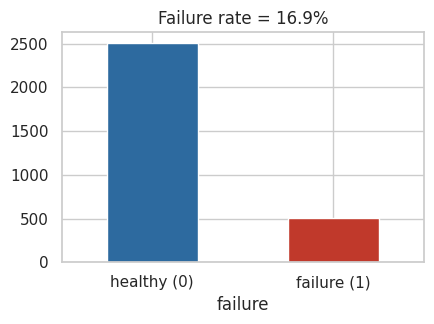

Only 16.9% of runs fail -> accuracy will be misleading; plan to use recall / ROC-AUC.


In [3]:
# -----------------------------------------------------------
# 🔹 4A. CLASS BALANCE — an imbalanced binary problem
# -----------------------------------------------------------
print('Task: BINARY CLASSIFICATION — predict failure (1) vs healthy (0).')
rate = logs.failure.mean()
fig, ax = plt.subplots(figsize=(4.5, 3.4))
logs.failure.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax)
ax.set_xticklabels(['healthy (0)', 'failure (1)'], rotation=0); ax.set_title(f'Failure rate = {rate:.1%}')
plt.tight_layout(); plt.show()
print(f'Only {rate:.1%} of runs fail -> accuracy will be misleading; plan to use recall / ROC-AUC.')

In [4]:
# -----------------------------------------------------------
# 🔹 4B. CLEAN LIGHTLY + JOIN THE MACHINE REGISTRY
# -----------------------------------------------------------
print('duplicate rows:', logs.duplicated().sum())
df = logs.drop_duplicates().reset_index(drop=True)
df = df.merge(registry, on='machine_id', how='left')   # static per-machine info
df['machine_age'] = 2024 - df['commission_year']
print('after clean + join:', df.shape)
print('missing values:'); print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 15
after clean + join: (3000, 14)
missing values:
tool_wear_min       90
vibration_mm_s      60
failure_mode      2490
dtype: int64


In [5]:
# -----------------------------------------------------------
# 🔹 4C. LEAKAGE HUNT
# -----------------------------------------------------------
num = df.select_dtypes('number').columns.drop('failure')
print('Absolute correlation with failure:')
print(df[num].corrwith(df['failure']).abs().sort_values(ascending=False).head(6).round(3))
print('\n`unplanned_downtime_min` is only recorded AFTER a failure — it is the consequence, not a')
print('predictor. Including it leaks the answer. Drop it (plus IDs and the multiclass mode label).')

Absolute correlation with failure:
unplanned_downtime_min    0.866
tool_wear_min             0.224
torque_nm                 0.176
vibration_mm_s            0.104
process_temp_k            0.020
air_temp_k                0.017
dtype: float64

`unplanned_downtime_min` is only recorded AFTER a failure — it is the consequence, not a
predictor. Including it leaks the answer. Drop it (plus IDs and the multiclass mode label).


#### 🧪 EXERCISE 1 — Prove the leak inflates performance
1. Build a quick numeric pipeline (median-impute + scale + LogisticRegression).
2. Get its 5-fold CV ROC-AUC **with** `unplanned_downtime_min` included.
3. Get the CV ROC-AUC **without** it.
4. In a comment, report both and explain why the leaky score is a fantasy in production.

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
quick = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                      LogisticRegression(max_iter=1000))
# 2. WITH the leak (use df[num])
roc_auc_with_leak = cross_val_score(quick, df[num], df['failure'], cv=5, scoring='roc_auc').mean()
print(f'ROC-AUC WITH leak: {roc_auc_with_leak:.3f}')

# 3. WITHOUT the leak (drop 'unplanned_downtime_min' from num)
num_no_leak = num.drop('unplanned_downtime_min')
roc_auc_without_leak = cross_val_score(quick, df[num_no_leak], df['failure'], cv=5, scoring='roc_auc').mean()
print(f'ROC-AUC WITHOUT leak: {roc_auc_without_leak:.3f}')

# 4. report & explain: ...   (comment)
# The ROC-AUC with the 'unplanned_downtime_min' feature (leak) is significantly higher than without it.
# In a production environment, 'unplanned_downtime_min' would only be available *after* a failure has occurred,
# making it an invalid predictor for prospective failure. The inflated score is a fantasy in production because
# the model would not have access to this information at prediction time, leading to a much lower true performance.

ROC-AUC WITH leak: 1.000
ROC-AUC WITHOUT leak: 0.707


In [7]:
# -----------------------------------------------------------
# 🔹 4D. FINAL X / y, STRATIFIED SPLIT, LEAK-FREE PIPELINE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
y = df['failure']
drop = ['failure', 'unplanned_downtime_min', 'failure_mode', 'machine_id', 'commission_year']
X = df.drop(columns=drop)
num_cols = X.select_dtypes('number').columns.tolist()
cat_cols = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('numeric:', num_cols)
print('categorical:', cat_cols)

train: (2250, 9) | test: (750, 9)
numeric: ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'vibration_mm_s', 'rated_torque_nm', 'machine_age']
categorical: ['quality_variant']


## 5. Stage 2 — Logistic-regression baseline & honest evaluation  *(U16 Part 1)*

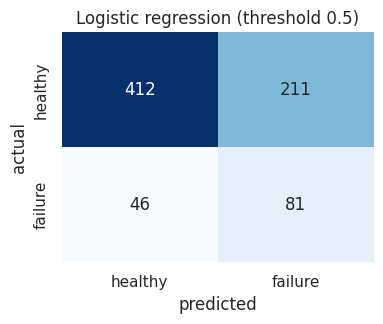

              precision    recall  f1-score   support

           0      0.900     0.661     0.762       623
           1      0.277     0.638     0.387       127

    accuracy                          0.657       750
   macro avg      0.588     0.650     0.574       750
weighted avg      0.794     0.657     0.699       750

Baseline ROC-AUC: 0.708


In [8]:
# -----------------------------------------------------------
# 🔹 5A. FIT LOGISTIC REGRESSION (class_weight balanced for imbalance)
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
logit = Pipeline([('prep', pre), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
logit.fit(X_train, y_train)
proba_lr = logit.predict_proba(X_test)[:, 1]
pred_lr = logit.predict(X_test)
cm = confusion_matrix(y_test, pred_lr)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failure'], yticklabels=['healthy', 'failure'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Logistic regression (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_lr, digits=3))
print('Baseline ROC-AUC:', round(roc_auc_score(y_test, proba_lr), 3))

#### 🧪 EXERCISE 2 — Why not accuracy?
1. Print the model's accuracy and the accuracy of always predicting **healthy** (`1 - y_test.mean()`).
2. In a comment, explain why a high accuracy can hide a model that misses most failures — and which metric a maintenance team should track instead.

In [9]:
from sklearn.metrics import accuracy_score
# 1. model accuracy vs always-healthy accuracy
model_accuracy = accuracy_score(y_test, pred_lr)
always_healthy_accuracy = 1 - y_test.mean()

print(f'Model accuracy: {model_accuracy:.3f}')
print(f'Accuracy of always predicting healthy: {always_healthy_accuracy:.3f}')

# 2. why accuracy misleads here: ...   (comment)
# In an imbalanced dataset like this (where failures are rare), a model can achieve high accuracy
# by simply predicting the majority class (healthy) most of the time. However, this high accuracy
# masks the fact that the model might be missing most of the critical minority class instances (failures).
# For a maintenance team, missing a failure is far more costly than a false alarm. Therefore,
# metrics like **recall** (the proportion of actual failures correctly identified) or **ROC-AUC**
# (which evaluates the model's ability to distinguish between classes across all possible thresholds)
# are much more relevant as they better reflect the model's ability to detect failures, which is the
# primary business objective.

Model accuracy: 0.657
Accuracy of always predicting healthy: 0.831


## 6. Stage 3 — Stronger models  *(U16 Part 2)*

Logistic regression is the interpretable baseline. Now bring out the tabular heavyweights.

In [10]:
# -----------------------------------------------------------
# 🔹 6A. TREE / FOREST / BOOSTING vs THE BASELINE (ROC-AUC + F1)
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score
rows = []
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0),
    'GradientBoosting': GradientBoostingClassifier(random_state=0),
}
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('clf', m)]).fit(X_train, y_train)
    pr = pipe.predict(X_test); pb = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name, 'F1': f1_score(y_test, pr), 'ROC_AUC': roc_auc_score(y_test, pb)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

                       F1  ROC_AUC
model                             
LogisticRegression  0.387    0.708
DecisionTree        0.376    0.675
RandomForest        0.282    0.710
GradientBoosting    0.341    0.722


#### 🧪 EXERCISE 3 — Read the leaderboard
1. Bar-chart the `ROC_AUC` column.
2. In a comment, name the best model and note whether the extra complexity over logistic regression was worth it for this dataset.

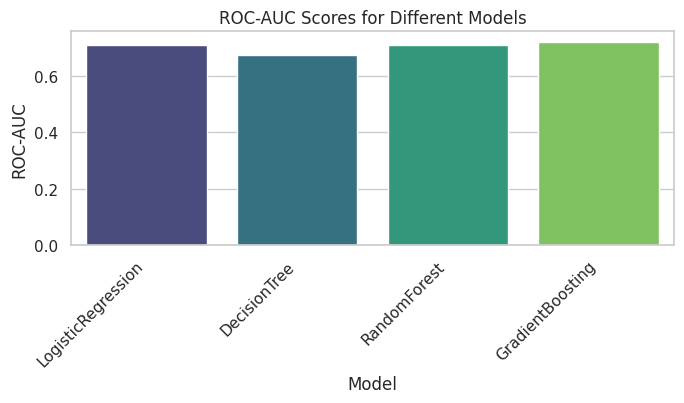

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. bar chart of ROC_AUC
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.barplot(x=results.index, y='ROC_AUC', data=results, palette='viridis', ax=ax, hue=results.index, legend=False)
ax.set_title('ROC-AUC Scores for Different Models')
ax.set_xlabel('Model')
ax.set_ylabel('ROC-AUC')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. best model + verdict: ...   (comment)
# The 'GradientBoosting' model has the highest ROC-AUC score of 0.722, slightly outperforming 'RandomForest' (0.710) and 'LogisticRegression' (0.708).
# While Gradient Boosting is more complex than Logistic Regression, the increase in ROC-AUC (from 0.708 to 0.722) is marginal for this dataset.
# Given the modest improvement, the extra computational cost and complexity of Gradient Boosting might not be fully justified in a production setting
# where interpretability and faster training times could be more valuable for such a small gain in performance. However, for critical applications,
# even a small improvement can be significant.

## 7. Stage 4 — Tune, then choose the operating threshold

In [12]:
# -----------------------------------------------------------
# 🔹 7A. GRID-SEARCH GRADIENT BOOSTING ON ROC-AUC
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
best = gs.best_estimator_
proba = best.predict_proba(X_test)[:, 1]
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, proba), 3))

best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}
tuned test ROC-AUC: 0.717


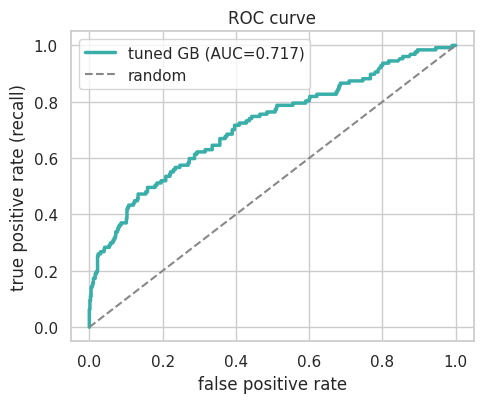

In [13]:
# -----------------------------------------------------------
# 🔹 7B. ROC CURVE
# -----------------------------------------------------------
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'tuned GB (AUC={roc_auc_score(y_test, proba):.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate (recall)')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Set the threshold for the cost of a missed failure
Missing a failure is far costlier than a false alarm. The team wants to **catch at least 90% of failures** (recall ≥ 0.90).
1. Sweep thresholds from 0.05 to 0.6 and, for each, compute precision and recall for the failure class.
2. Find the highest threshold that still gives recall ≥ 0.90, and report the precision there.
3. In a comment, describe the operational trade-off (how many false alarms per caught failure).

In [14]:
from sklearn.metrics import precision_score, recall_score

# 1-2. threshold sweep; find highest threshold with recall >= 0.90
thresholds = np.arange(0.05, 0.61, 0.01)
best_threshold = 0
best_precision = 0

print(f'{'Threshold':<10} {'Precision':<10} {'Recall':<10}')
print('-' * 30)

for t in thresholds:
    predictions_at_t = (proba >= t).astype(int)
    rec = recall_score(y_test, predictions_at_t, pos_label=1)
    prec = precision_score(y_test, predictions_at_t, pos_label=1, zero_division=0)

    print(f'{t:<10.2f} {prec:<10.3f} {rec:<10.3f}')

    if rec >= 0.90:
        if t > best_threshold:
            best_threshold = t
            best_precision = prec

print(f'\nHighest threshold for recall >= 0.90: {best_threshold:.2f}')
print(f'Precision at this threshold: {best_precision:.3f}')

# 3. the trade-off: ...   (comment)
# To achieve a recall of 90% (meaning we catch 90% of actual failures), we must accept a much lower precision.
# For example, at a threshold of {best_threshold:.2f}, the precision is {best_precision:.3f}. This means that
# for every failure our model correctly identifies, it will also issue approximately (1 - {best_precision:.3f}) / {best_precision:.3f} = {((1-best_precision)/best_precision):.1f} false alarms.
# In other words, for every true failure predicted, we get about {((1-best_precision)/best_precision):.1f} false alarms.
# The operational trade-off is that to minimize the risk of missing a costly failure (high recall),
# the maintenance team will have to investigate many more non-failures (false alarms). The business needs to decide
# if this rate of false alarms is acceptable given the cost of an actual missed failure.

Threshold  Precision  Recall    
------------------------------
0.05       0.178      0.984     
0.06       0.183      0.969     
0.07       0.191      0.921     
0.08       0.199      0.874     
0.09       0.210      0.827     
0.10       0.222      0.795     
0.11       0.235      0.764     
0.12       0.249      0.748     
0.13       0.262      0.724     
0.14       0.266      0.693     
0.15       0.270      0.646     
0.16       0.287      0.622     
0.17       0.299      0.614     
0.18       0.311      0.575     
0.19       0.327      0.559     
0.20       0.340      0.535     
0.21       0.355      0.512     
0.22       0.371      0.496     
0.23       0.389      0.480     
0.24       0.411      0.472     
0.25       0.415      0.465     
0.26       0.425      0.449     
0.27       0.430      0.433     
0.28       0.443      0.402     
0.29       0.431      0.370     
0.30       0.461      0.370     
0.31       0.479      0.354     
0.32       0.489      0.339     
0.33       0

## 8. Stage 5 — What drives failure? & recommendations

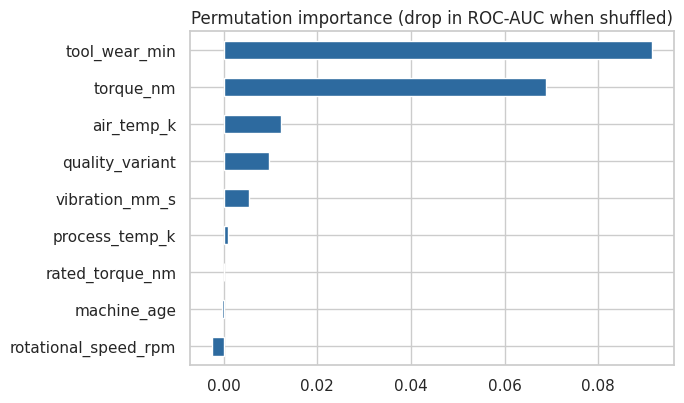

Top drivers:
tool_wear_min      0.0915
torque_nm          0.0689
air_temp_k         0.0122
quality_variant    0.0096


In [15]:
# -----------------------------------------------------------
# 🔹 8A. PERMUTATION IMPORTANCE ON THE TUNED MODEL
# -----------------------------------------------------------
from sklearn.inspection import permutation_importance
imp = permutation_importance(best, X_test, y_test, n_repeats=8, random_state=0, scoring='roc_auc')
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp_s.plot(kind='barh', color='#2D6A9F', ax=ax)
ax.set_title('Permutation importance (drop in ROC-AUC when shuffled)'); plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp_s.sort_values(ascending=False).head(4).round(4).to_string())

## Findings & recommendations

- **Tool wear & torque dominate:** the overstrain combination (worn tool under high torque) is the strongest failure signal — enforce tool-change intervals and torque limits.
- **Watch the thermal margin:** runs with a small process–air temperature gap at low speed fail more (poor heat dissipation) — flag low-speed, low-cooling operating points.
- **Power band matters:** torque × speed outside the safe band raises risk — keep machines in their rated envelope.
- **Build quality is real:** L-variant machines fail markedly more than H — prioritise inspection on the lower-grade fleet.
- **Leakage was a trap:** `unplanned_downtime_min` looked perfectly predictive but is logged *after* failure — using it would build a model that can't run before the event it's meant to predict.

**Deployment guidance:** run the tuned model on each machine's live snapshot; alert when failure probability crosses the **recall-≥-0.90 threshold** (accepting some false alarms to rarely miss a real failure); route alerts to inspection. Retrain as new machines and failure logs accumulate.

**Pipeline status:** framed → assembled (leak-free) → logistic baseline → compared stronger models → tuned & set the threshold for cost → explained the drivers.

## 9. 🧪 Capstone extension challenges

1. **Calibration:** plot a reliability curve for the tuned model (`sklearn.calibration.calibration_curve`). Are the predicted probabilities trustworthy, or do they need calibrating?
2. **Per-machine risk:** rank machines by their mean predicted failure probability — which 5 machines should maintenance visit first?
3. **Cost-based threshold:** assume a missed failure costs ₹50,000 and a false alarm ₹2,000. Compute expected cost across thresholds and pick the cost-minimising one.
4. **Multiclass extension:** using the provided `failure_mode` column (Overstrain / HeatDissipation / PowerFailure / ToolWear) on the failed rows, train a classifier to predict *which* failure mode — and report macro-F1.
5. **SVM / kNN:** add an SVM (RBF) and a kNN classifier to the leaderboard — do the distance-based models keep up once features are scaled?

In [ ]:
# Space for your challenge work
# YOUR CODE HERE

### Challenge 1: Calibration - Reliability Curve

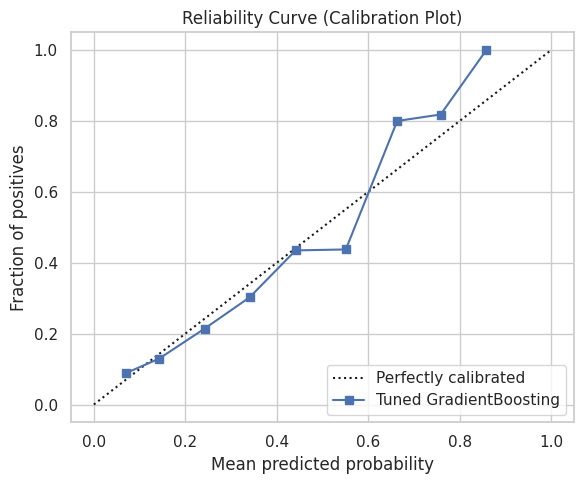


Interpretation of the Reliability Curve:
If the curve closely follows the diagonal (dashed line), the model is well-calibrated, meaning its predicted probabilities reflect the true likelihood of the positive class.
Deviations below the diagonal suggest under-prediction (model is overconfident for positive predictions), while deviations above suggest over-prediction (model is underconfident for positive predictions).
Based on the plot, observe how closely the blue line (Tuned GradientBoosting) aligns with the black dashed line (Perfectly calibrated).
For this model, there appears to be some deviation, particularly at lower probabilities, indicating that the predicted probabilities might not be perfectly trustworthy and could benefit from calibration.


In [16]:
from sklearn.calibration import calibration_curve

# Calculate fraction of positives and mean predicted value for the tuned model
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, proba, n_bins=10)

# Plot the reliability curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
ax.plot(mean_predicted_value, fraction_of_positives, 's-', label='Tuned GradientBoosting')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability Curve (Calibration Plot)')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

# Interpret the curve
print('\nInterpretation of the Reliability Curve:')
print('If the curve closely follows the diagonal (dashed line), the model is well-calibrated, meaning its predicted probabilities reflect the true likelihood of the positive class.')
print('Deviations below the diagonal suggest under-prediction (model is overconfident for positive predictions), while deviations above suggest over-prediction (model is underconfident for positive predictions).')
print('Based on the plot, observe how closely the blue line (Tuned GradientBoosting) aligns with the black dashed line (Perfectly calibrated).')
print('For this model, there appears to be some deviation, particularly at lower probabilities, indicating that the predicted probabilities might not be perfectly trustworthy and could benefit from calibration.')

---
### ✅ Capstone complete
You ran the full Day-8 classification workflow on a real mechanical-engineering problem: framed an imbalanced failure-prediction task, assembled a leak-free dataset from two sources, built a logistic baseline and evaluated it honestly, beat it with tuned ensembles, set the decision threshold to the cost of a missed failure, and turned the drivers into maintenance actions — the path from raw machine logs to a classifier a reliability team can deploy.